Reference: https://www.10xgenomics.com/analysis-guides/xenium-downstream-analysis-in-python-tutorial

## 1. Install packages and download the data

### 1.1 Install and import the Python packages

`spatial_env` environment

In [1]:
# micromamba env create -f environment.yml

In [1]:
# Import the python packages. Rerun this code again if you encounter an error on xarray_schema.
import scanpy as sc
import pandas as pd
import numpy as np
import h5py
import anndata as ad
import matplotlib.pyplot as plt
import warnings
import os
import squidpy as sq
import spatialdata as sd
import spatialdata_io as sio
import spatialdata_plot

%load_ext autoreload
%autoreload 2

warnings.filterwarnings("ignore")

/home/duydao/micromamba/envs/spatial_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Xenium data visualization and analysis (single sample)

### SpatialData overview

SpatialData is a flexible framework for loading and analyzing Xenium data. It organizes data into 5 main object types:

- **Images** — the Xenium morphology or H&E/IF images (e.g. `morphology_focus` OME-TIFFs).
- **Labels** — segmentation masks provided by Xenium (cell and nucleus labels).
- **Points** — transcript locations (`transcripts.parquet`).
- **Shapes** — cell/nucleus segmentation boundaries from Xenium onboard analysis.
- **Tables** — the gene expression count matrix (cells x genes) as an `AnnData` object, analyzable like standard single-cell data.

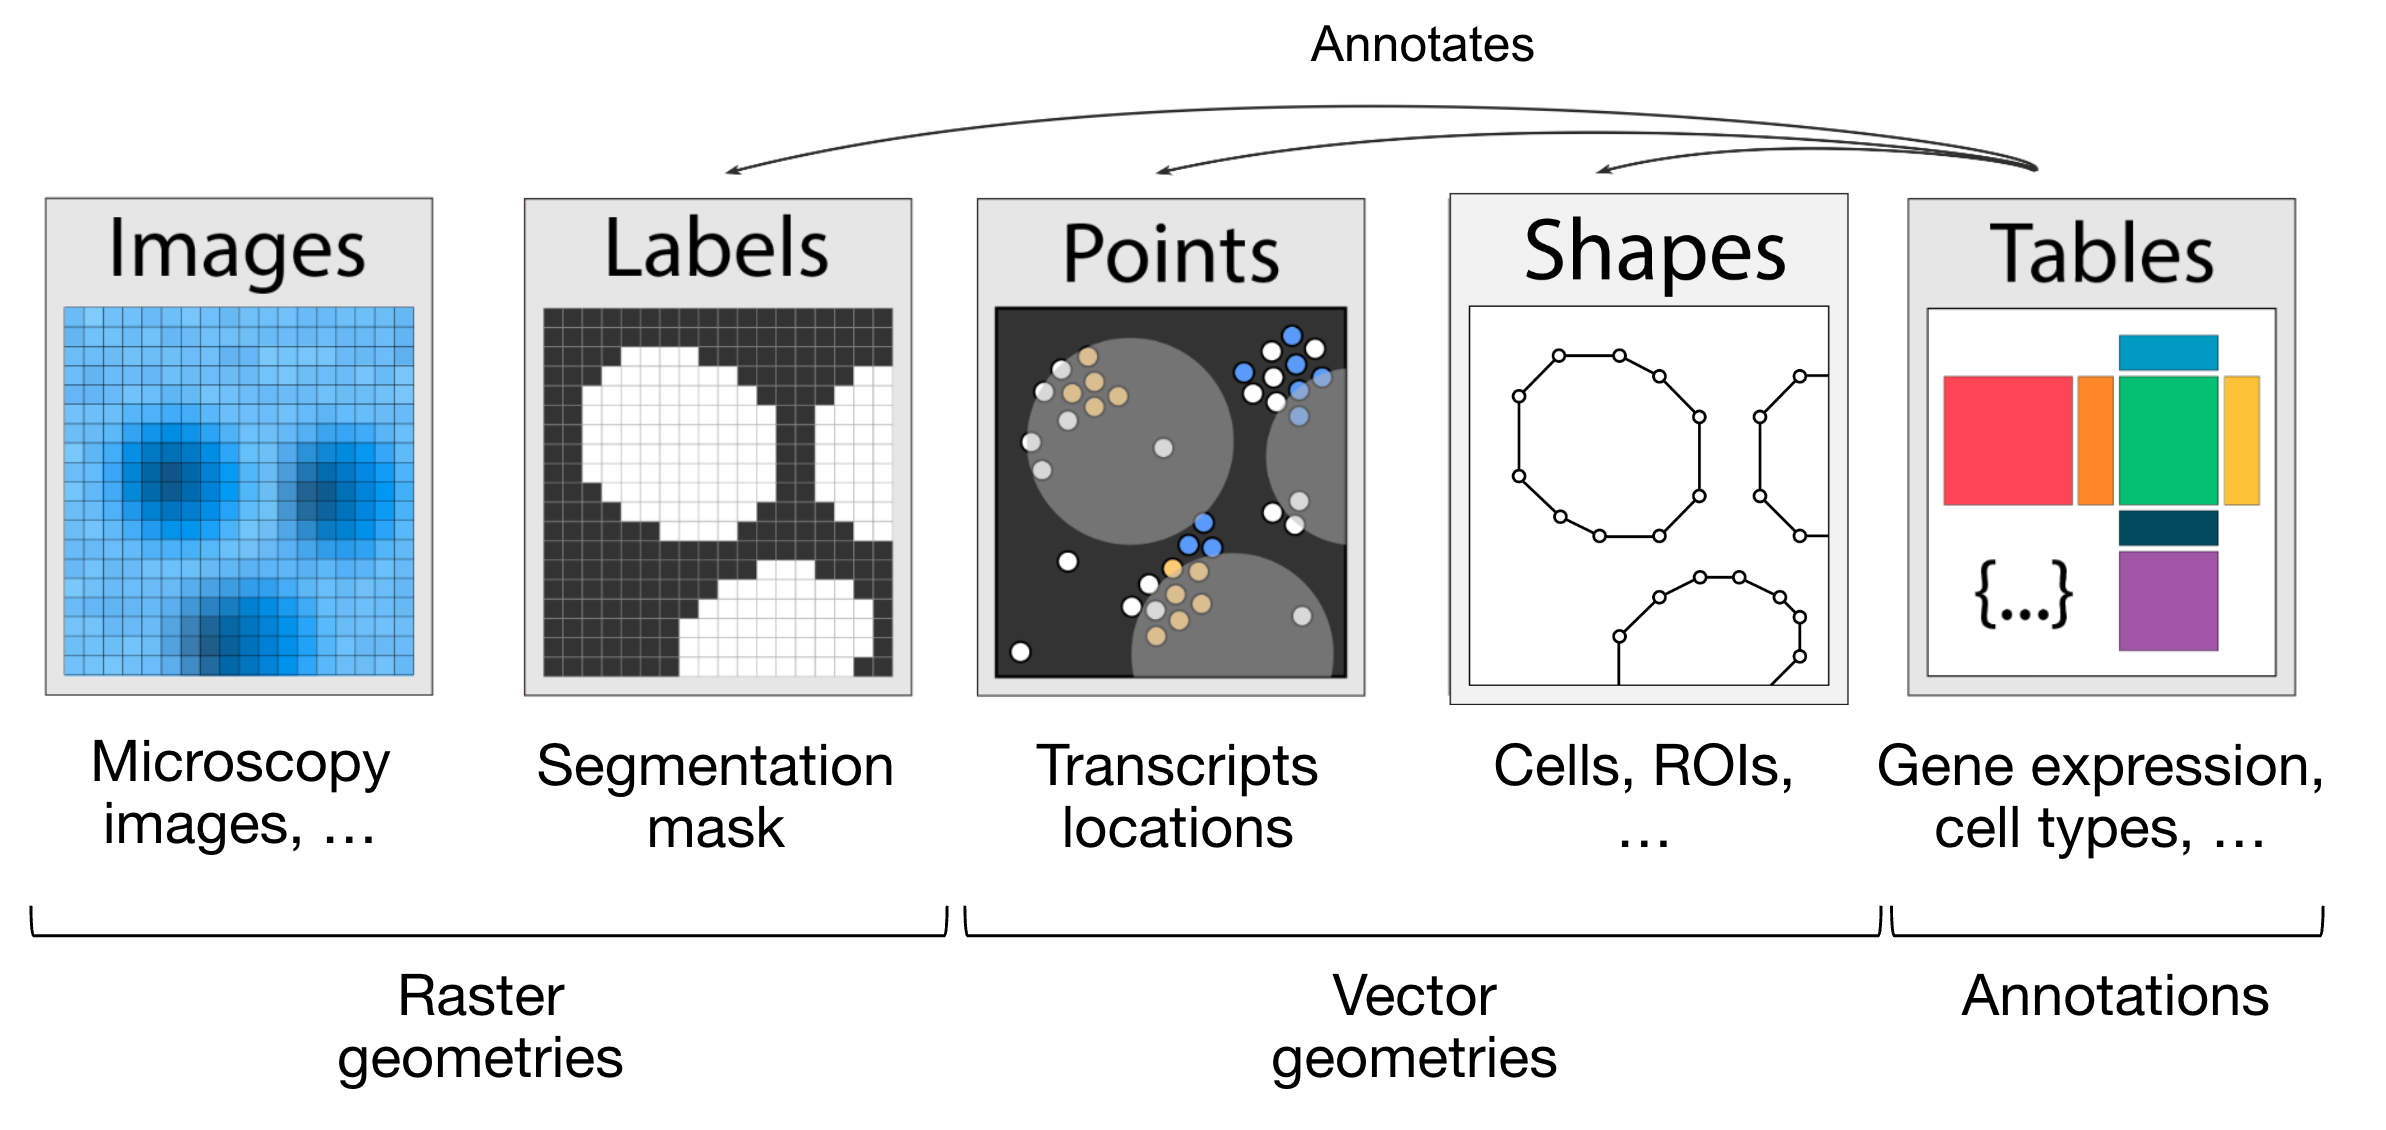

### 2.1 Load the data

Un-comment if we want to create the spatialdata from the bundle.

In [ ]:
# Build the SpatialData object directly from the raw Xenium bundle
# sdata = sio.xenium("../../data/raw/xenium_5k/bundle/")

In [4]:
# # Fix the string-based cell/nucleus boundary index for napari compatibility
# for shape_name in ["cell_boundaries", "nucleus_boundaries"]:
#     if shape_name in sdata.shapes:
#         boundaries = sdata.shapes[shape_name]
#         boundaries["cell_id_str"] = boundaries.index.astype(str)
#         sdata.shapes[shape_name] = boundaries.reset_index(drop=True)

In [5]:
# # Persist the SpatialData object to disk as a Zarr store
# sdata.write("../../data/spatialdata/xenium_prime_5k.zarr", overwrite=True)

In [6]:
sdata = sd.SpatialData.read("../../data/spatialdata/xenium_prime_5k.zarr")

no parent found for <ome_zarr.reader.Label object at 0x76eef9e569c0>: None
no parent found for <ome_zarr.reader.Label object at 0x76eef9e7aff0>: None


In [7]:
sdata

SpatialData object, with associated Zarr store: /worker_data1/duy_spatial/xenium_lung/data/spatialdata/xenium_prime_5k.zarr
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 43270, 26720), (3, 21635, 13360), (3, 10817, 6680), (3, 5408, 3340), (3, 2704, 1670)
│     └── 'morphology_focus': DataTree[cyx] (4, 37348, 54086), (4, 18674, 27043), (4, 9337, 13521), (4, 4668, 6760), (4, 2334, 3380)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (37348, 54086), (18674, 27043), (9337, 13521), (4668, 6760), (2334, 3380)
│     └── 'nucleus_labels': DataTree[yx] (37348, 54086), (18674, 27043), (9337, 13521), (4668, 6760), (2334, 3380)
├── Points
│     └── 'transcripts': DataFrame with shape: (177464221, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (278328, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (277935, 3) (2D shapes)
└── Tables
      └── 'table': AnnData (278328, 5001)
with coordinate systems:
    ▸ 'global', with elements:
        he_ima

In [8]:
sdata["morphology_focus"]

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 4, y: 37348, x: 54086)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 299kB 0.5 1.5 2.5 3.5 ... 3.735e+04 3.735e+04 3.735e+04
│         * x        (x) float64 433kB 0.5 1.5 2.5 3.5 ... 5.408e+04 5.408e+04 5.409e+04
│       Data variables:
│           image    (c, y, x) uint16 16GB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 4, y: 18674, x: 27043)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 149kB 1.0 3.0 5.0 7.0 ... 3.734e+04 3.734e+04 3.735e+04
│         * x        (x) float64 216kB 1.0 3.0 5.0 7.0 ... 5.408e+04 5.408e+04 5.408e+04
│       Data variables:
│           image    (c, y, x) uint16 4GB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 4, y: 9337, x: 13521)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 75kB 2.0 6.0 10.0 ... 3.734e+04 3.734e+04 3.735e+04
│         * x        (x) float64 108kB 2.0 6.0 10.0 ... 5.408e+04 5.408e+04 5.408e+04
│       Data variables:
│           image    (c, y, x) uint16 1GB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (c: 4, y: 4668, x: 6760)
│       Coordinates:
│         * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
│         * y        (y) float64 37kB 4.0 12.0 20.0 ... 3.733e+04 3.734e+04 3.734e+04
│         * x        (x) float64 54kB 4.0 12.0 20.0 ... 5.407e+04 5.407e+04 5.408e+04
│       Data variables:
│           image    (c, y, x) uint16 252MB dask.array<chunksize=(1, 4096, 4096), meta=np.ndarray>
└── Group: /scale4
        Dimensions:  (c: 4, y: 2334, x: 3380)
        Coordinates:
          * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
          * y        (y) float64 19kB 8.001 24.0 40.0 ... 3.731e+04 3.732e+04 3.734e+04
          * x        (x) float64 27kB 8.001 24.0 40.0 ... 5.405e+04 5.406e+04 5.408e+04
        Data variables:
            image    (c, y, x) uint16 63MB dask.array<chunksize=(1, 2334, 3380), meta=np.ndarray>

In [9]:
sd.get_pyramid_levels(sdata["morphology_focus"], n=0)

<xarray.DataArray 'image' (c: 4, y: 37348, x: 54086)> Size: 16GB
dask.array<from-zarr, shape=(4, 37348, 54086), dtype=uint16, chunksize=(1, 4096, 4096), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U22 352B 'DAPI' ... 'AlphaSMA/Vimentin'
  * y        (y) float64 299kB 0.5 1.5 2.5 3.5 ... 3.735e+04 3.735e+04 3.735e+04
  * x        (x) float64 433kB 0.5 1.5 2.5 3.5 ... 5.408e+04 5.408e+04 5.409e+04
Attributes:
    transform:  {'global': Identity }

### 2.2 Transcript and cell plotting functions

The "cell_boundaries" shapes give the spatial location and shape of cells, while the "table" object holds gene expression. We link them with `set_table_annotates_spatialelement`. For cells, use `render_shapes`; for transcripts, use `render_points`. See the [spatialdata plotting docs](https://spatialdata.scverse.org/projects/plot/en/stable/plotting.html) for details.

WARNING  render_shapes: Found 1 NaN values in color data. These observations will be colored with the 'na_color'.  


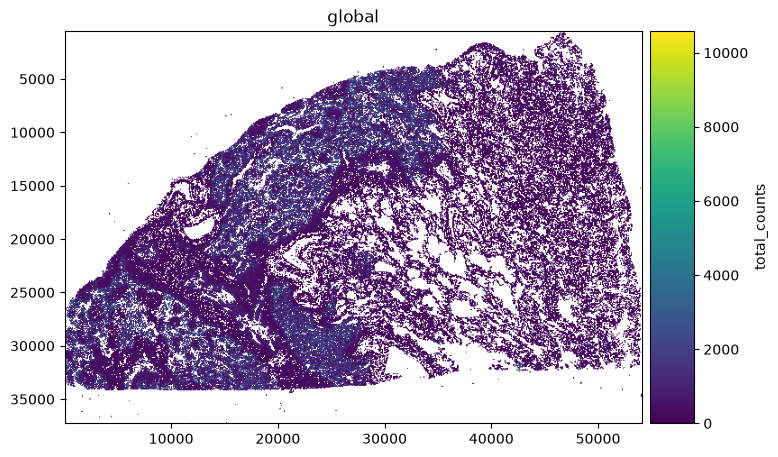

In [10]:
# Link the table (expression) to the cell_boundaries shapes so we can color cells by obs columns
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

# The x and y axis are pixel coordinates
sdata.pl.render_shapes("cell_boundaries", color="total_counts").pl.show()

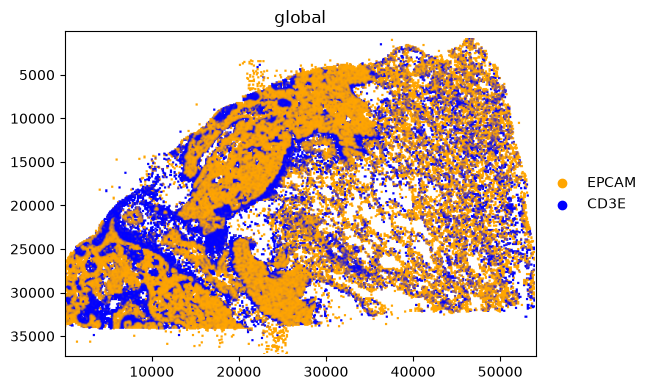

In [11]:
# EPCAM (epithelial/tumor) and CD3E (T cell) are both present in this gene panel
sdata.pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["EPCAM", "CD3E"],
    palette=["orange", "blue"],
).pl.show()

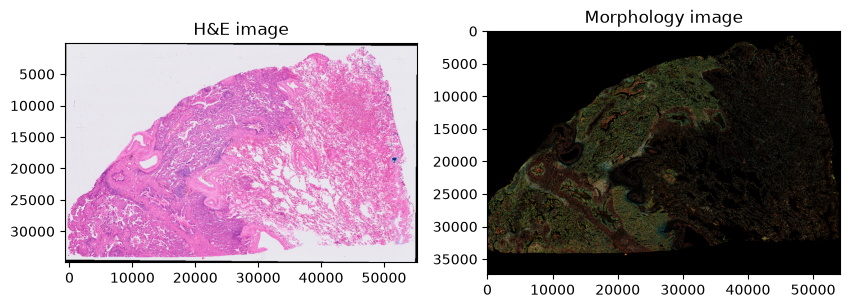

In [12]:
import matplotlib.pyplot as plt

axes = plt.subplots(1, 2, figsize=(10, 10))[1].flatten()
sdata.pl.render_images("he_image").pl.show(ax=axes[0], title="H&E image")
sdata.pl.render_images("morphology_focus").pl.show(ax=axes[1], title="Morphology image")

https://spatialdata.scverse.org/en/stable/tutorials/notebooks/notebooks/examples/technology_xenium.html

In [13]:
# from spatialdata import bounding_box_query

# axes = plt.subplots(3, 1, figsize=(20, 13))[1].flatten()


# def crop0(x):
#     return bounding_box_query(
#         x,
#         min_coordinate=[20_000, 8000],
#         max_coordinate=[22_000, 8500],
#         axes=("x", "y"),
#         target_coordinate_system="global",
#     )


# crop0(sdata).pl.render_images("he_image").pl.show(ax=axes[0], title="H&E image", coordinate_systems="global")
# crop0(sdata).pl.render_images("morphology_focus", channel="DAPI").pl.show(
#     ax=axes[1], title="Morphology image", coordinate_systems="global", colorbar=False
# )
# crop0(sdata).pl.render_labels("cell_labels").pl.show(ax=axes[2], title="Cell labels", coordinate_systems="global")

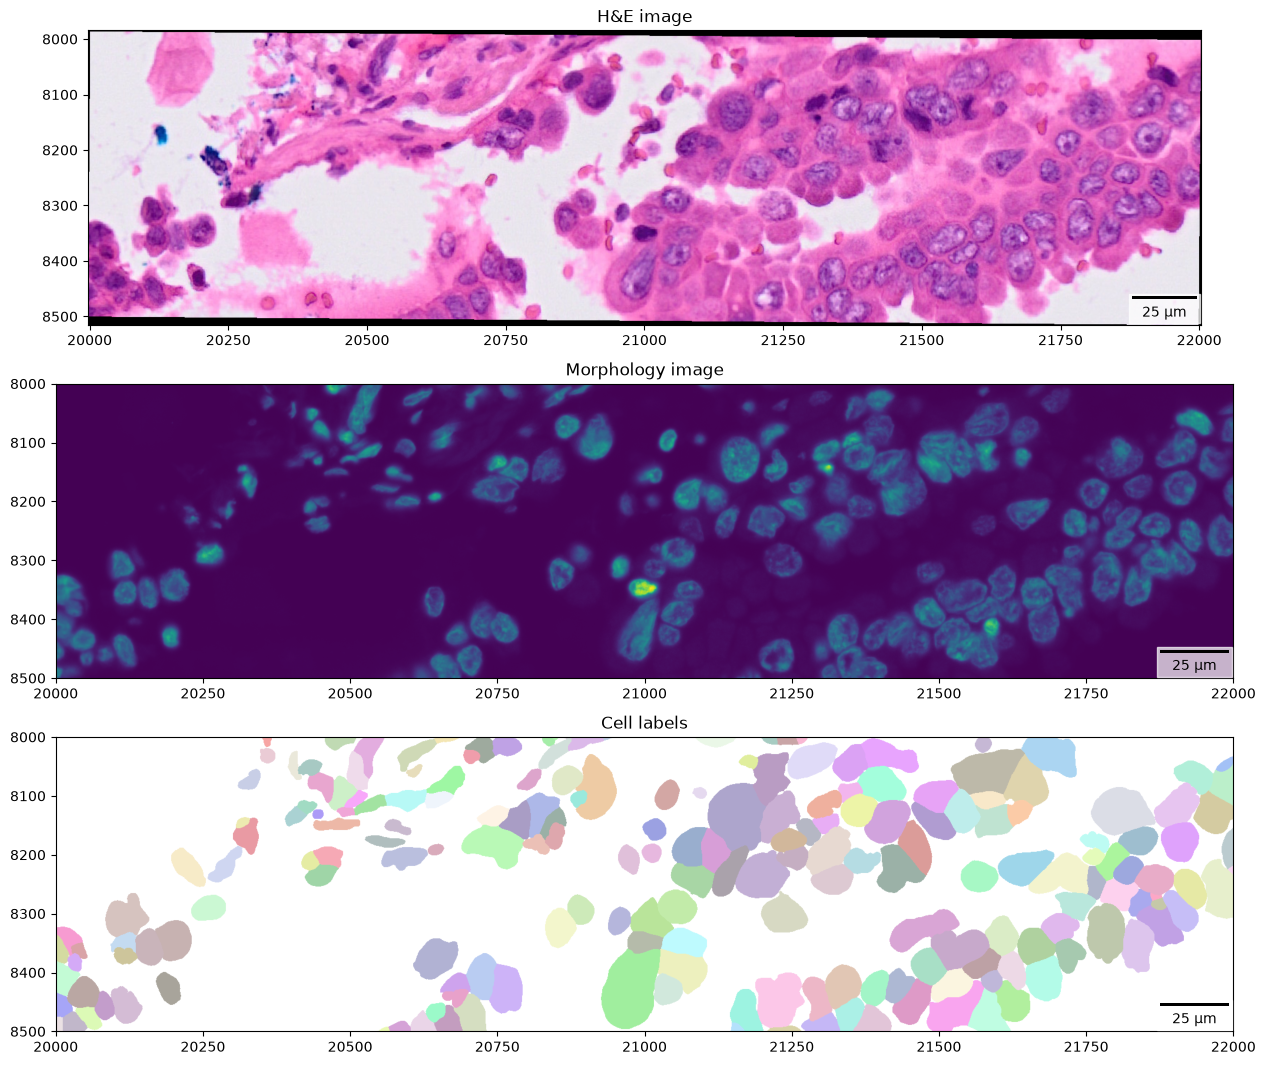

In [ ]:
from spatialdata import bounding_box_query
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.pyplot as plt

axes = plt.subplots(3, 1, figsize=(20, 13))[1].flatten()

def crop0(x):
    return bounding_box_query(
        x,
        min_coordinate=[20_000, 8000],
        max_coordinate=[22_000, 8500],
        axes=("x", "y"),
        target_coordinate_system="global",
    )

# 1. Render your images and labels
crop0(sdata).pl.render_images("he_image").pl.show(ax=axes[0], title="H&E image", coordinate_systems="global")
crop0(sdata).pl.render_images("morphology_focus", channel="DAPI").pl.show(
    ax=axes[1], title="Morphology image", coordinate_systems="global", colorbar=False
)
crop0(sdata).pl.render_labels("cell_labels").pl.show(ax=axes[2], title="Cell labels", coordinate_systems="global")

# 2. Define your unit scale (Using 0.2125 assuming the axes are in raw pixels)
pixel_size_in_microns = 0.2125 

# 3. Add the scale bar to each axis
for ax in axes:
    scalebar = ScaleBar(
        dx=pixel_size_in_microns, 
        units="um", 
        location="lower right", 
        color="black", 
        box_color="white", 
        box_alpha=0.7, 
        length_fraction=0.1
    )
    ax.add_artist(scalebar)

### 2.3 Select sub-region of interest (optional)

There are two ways to select sub-regions of interest:

1. By coordinates
2. By cell IDs

The cells below are templates: export a coordinate polygon or a list of cell IDs from napari for your own region of interest, then update the placeholder values/paths before uncommenting and running.

In [15]:
from spatialdata import bounding_box_query

# Napari rectangle ROI exported as (index, shape-type, vertex-index, axis-0, axis-1, axis-2); axis-1/2 are Y/X in pixels
roi = pd.read_csv("../../data/tables/morphology_focus_rois.csv")
min_x, max_x = roi["axis-2"].min(), roi["axis-2"].max()
min_y, max_y = roi["axis-1"].min(), roi["axis-1"].max()

cropped_sdata = bounding_box_query(
    sdata,
    min_coordinate=[min_x, min_y],
    max_coordinate=[max_x, max_y],
    axes=("x", "y"),
    target_coordinate_system="global",
)

In [16]:
cropped_sdata.tables

{'table': AnnData object with n_obs × n_vars = 1163 × 5001
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'region', 'z_level', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'
    layers: None (.X)}

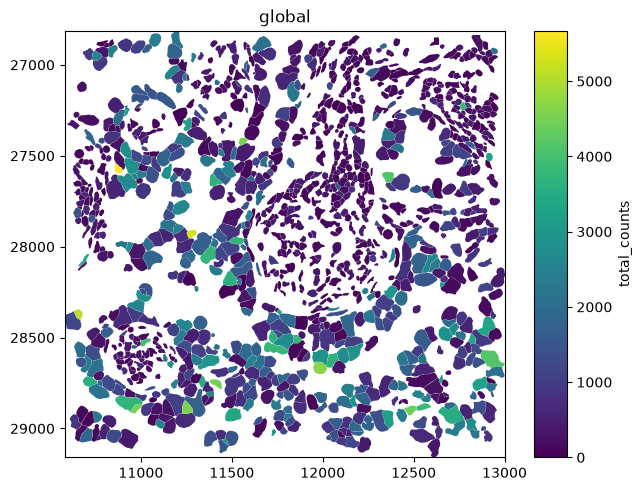

In [17]:
cropped_sdata.tables["table"].obs["region"] = "cell_boundaries"
cropped_sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")
cropped_sdata.pl.render_shapes("cell_boundaries", color="total_counts").pl.show()

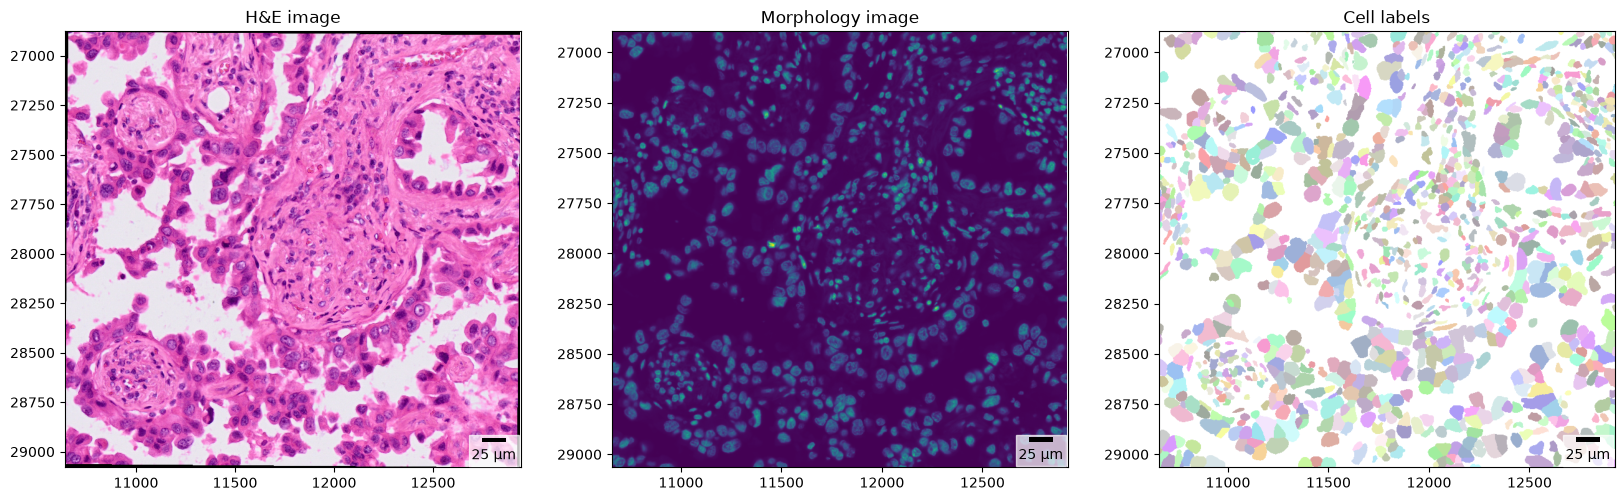

In [18]:
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.pyplot as plt

axes = plt.subplots(1, 3, figsize=(20, 7))[1].flatten()

# 1. Render images and labels
cropped_sdata.pl.render_images("he_image").pl.show(ax=axes[0], title="H&E image", coordinate_systems="global")
cropped_sdata.pl.render_images("morphology_focus", channel="DAPI").pl.show(
    ax=axes[1], title="Morphology image", coordinate_systems="global", colorbar=False
)
cropped_sdata.pl.render_labels("cell_labels").pl.show(ax=axes[2], title="Cell labels", coordinate_systems="global")

# 2. Define unit scale
pixel_size_in_microns = 0.2125 

# 3. Add scale bar to each axis
for ax in axes:
    scalebar = ScaleBar(
        dx=pixel_size_in_microns, 
        units="um", 
        location="lower right", 
        color="black", 
        box_color="white", 
        box_alpha=0.7, 
        length_fraction=0.1
    )
    ax.add_artist(scalebar)

In [ ]:
# Template: replace with a CSV of selected cell IDs exported from napari, then uncomment to run
# select_cells = pd.read_csv("../../data/my_selection_cell_ids.csv")
#
# subset_sdata = sd.match_sdata_to_table(
#     sdata,
#     table=sdata["table"][sdata["table"].obs["cell_id"].isin(select_cells["Cell ID"])],
#     table_name="table",
#     how="right",
# )
# subset_sdata.pl.render_shapes("cell_boundaries", color="total_counts").pl.show()

Verify these spatially variable genes and cluster assignments visually in napari or Xenium Explorer using the exported `xenium_prime_5k_clustering.csv`.